# Stage B - Fine-tuning ResNet-18 Classifier
Train an ImageNet-pretrained ResNet-18 expert on 100 classes with freeze/unfreeze scheduling.

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import yaml
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Ensure imports from project root work regardless of notebook working directory.
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import get_dataloaders
from src.classifier import get_classifier
from src.train_classifier import train_classifier

In [2]:
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Resolve all important paths from the project root so notebook cwd does not matter.
data_root = (project_root / config['dataset']['root']).resolve()
models_dir = (project_root / 'models').resolve()
classifier_save_path = models_dir / 'resnet_classifier.pth'
classifier_ckpt_dir = models_dir / 'checkpoints' / 'classifier'

device = config['training']['device'] if torch.cuda.is_available() else 'cpu'
model = get_classifier(
    num_classes=config['dataset']['num_classes'],
    pretrained=config['classifier']['pretrained']
).to(device)
print(f'Using data root: {data_root}')
print(f'Checkpoint dir: {classifier_ckpt_dir}')
model

Using data root: C:\Users\Akash\Desktop\SelfHealingNN\data\raw
Checkpoint dir: C:\Users\Akash\Desktop\SelfHealingNN\models\checkpoints\classifier


SelfHealingClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

In [3]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,}')
print(f'Total params: {total:,}')

Trainable params: 11,227,812
Total params: 11,227,812


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    root=str(data_root),
    image_size=config['dataset']['image_size'],
    batch_size=config['classifier']['batch_size'],
    train_split=config['dataset']['train_split'],
    num_workers=config['training']['num_workers'],
    noisy=False
)

# Single-call training with freeze->unfreeze schedule is safer for checkpoint resume.
history = train_classifier(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=config['classifier']['epochs'],
    learning_rate=config['classifier']['learning_rate'],
    freeze_backbone_epochs=int(config['classifier'].get('freeze_backbone_epochs', 5)),
    save_path=str(classifier_save_path),
    patience=config['training']['early_stopping_patience'],
    checkpoint_dir=str(classifier_ckpt_dir),
    checkpoint_interval=config['training']['checkpoint_interval'],
    auto_resume=config['training']['auto_resume'],
    use_amp=config['training']['amp'],
    grad_clip_norm=config['training']['grad_clip_norm'],
    early_stop_metric=str(config['training'].get('classifier_early_stop_metric', 'val_top1')),
    weight_decay=float(config['classifier'].get('weight_decay', 1e-4)),
    label_smoothing=float(config['classifier'].get('label_smoothing', 0.1)),
    mixup_alpha=float(config['classifier'].get('mixup_alpha', 0.2)),
)

print('Training call complete. If interrupted, rerun this cell to resume from latest checkpoint.')

Epoch 001 | loss=0.9766/0.9210 | top1=0.9558/0.9665 | top5=0.9953/1.0000 | conf=0.8526/0.8687 | lr=9.97e-05


Epoch 002 | loss=0.9289/0.9184 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.8688/0.8816 | lr=9.89e-05


Epoch 003 | loss=0.9265/0.9170 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.8693/0.8783 | lr=9.76e-05


Epoch 004 | loss=0.9221/0.9062 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.8714/0.8802 | lr=9.97e-05


Epoch 005 | loss=0.9182/0.9046 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.8702/0.8694 | lr=9.87e-05


...

Epoch 007 | loss=0.9166/0.9046 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.8700/0.8646 | lr=9.47e-05


Epoch 008 | loss=0.9141/0.9060 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.8700/0.8675 | lr=9.18e-05


Epoch 009 | loss=0.9062/0.9158 | top1=0.9624/0.9664 | top5=1.0000/1.0000 | conf=0.8707/0.8762 | lr=8.83e-05


Epoch 010 | loss=0.8816/0.9326 | top1=0.9617/0.9604 | top5=0.9998/0.9997 | conf=0.8753/0.8619 | lr=8.43e-05


Epoch 011 | loss=0.8538/0.9383 | top1=0.9616/0.9613 | top5=0.9992/0.9988 | conf=0.8829/0.8792 | lr=7.99e-05
Early stopping triggered at epoch 11.
Training call complete. If interrupted, rerun this cell to resume from latest checkpoint.


In [5]:
# Resume note: this notebook now uses a single training call in Cell 5.
# If you stop training manually, just rerun Cell 5 and it will auto-resume from
# models/checkpoints/classifier/latest.pt.
print('Resume workflow enabled: rerun Cell 5 to continue training from latest checkpoint.')

Resume workflow enabled: rerun Cell 5 to continue training from latest checkpoint.


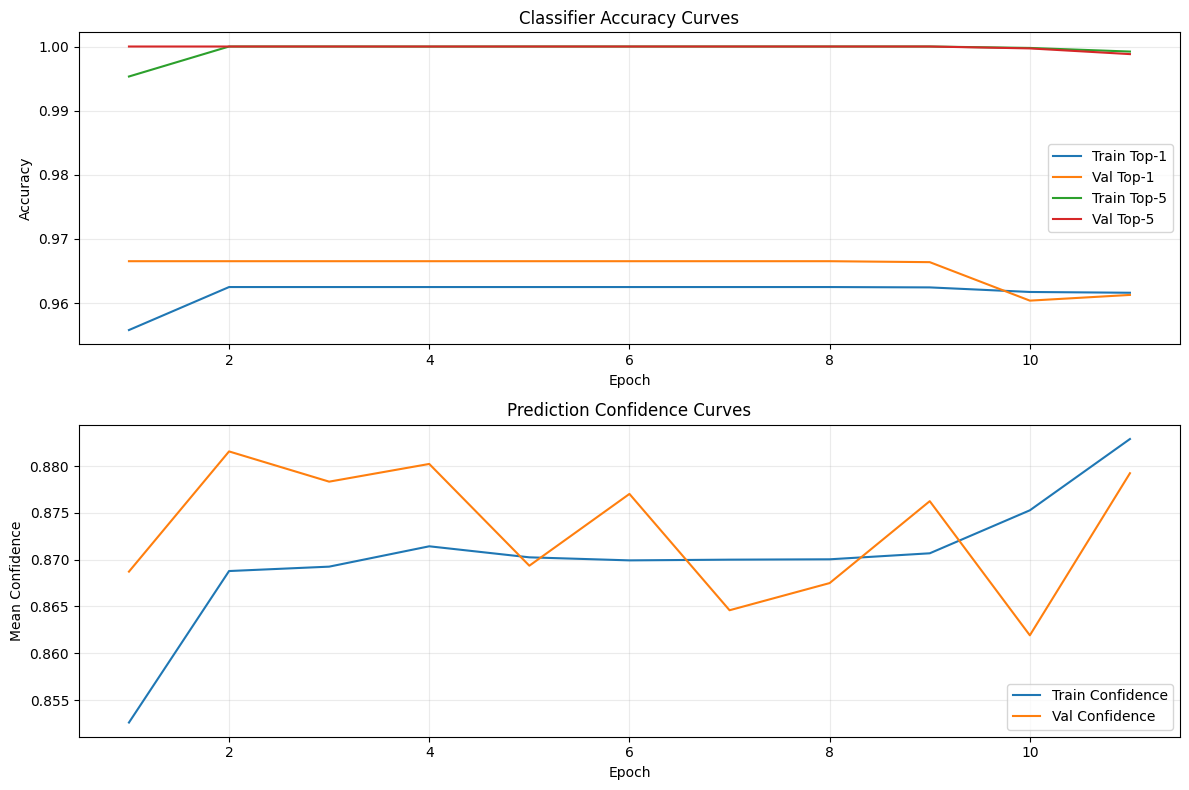

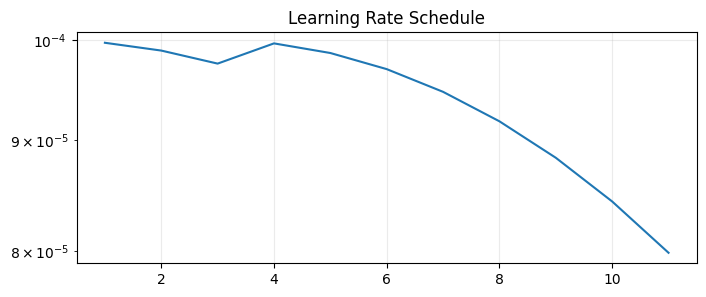

In [6]:
epochs = range(1, len(history['train_top1']) + 1)
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(epochs, history['train_top1'], label='Train Top-1')
plt.plot(epochs, history['val_top1'], label='Val Top-1')
plt.plot(epochs, history['train_top5'], label='Train Top-5')
plt.plot(epochs, history['val_top5'], label='Val Top-5')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracy Curves')
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(2, 1, 2)
plt.plot(epochs, history.get('train_confidence', []), label='Train Confidence')
plt.plot(epochs, history.get('val_confidence', []), label='Val Confidence')
plt.xlabel('Epoch')
plt.ylabel('Mean Confidence')
plt.title('Prediction Confidence Curves')
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

if history.get('lr'):
    plt.figure(figsize=(8, 3))
    plt.plot(epochs, history['lr'])
    plt.title('Learning Rate Schedule')
    plt.yscale('log')
    plt.grid(alpha=0.25)
    plt.show()

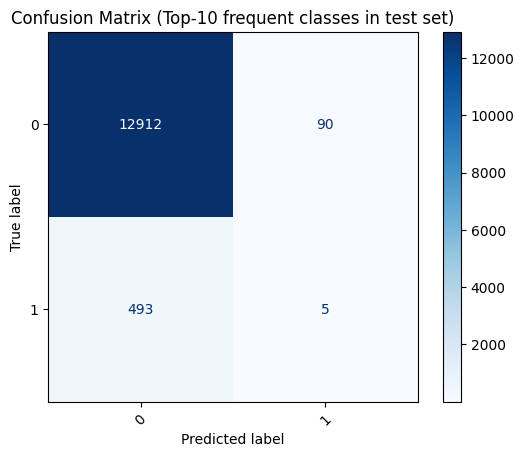

In [7]:
from collections import Counter

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

class_counts = Counter(all_targets.tolist())
sample_classes = [cls for cls, _ in class_counts.most_common(10)]
cm = confusion_matrix(all_targets, all_preds, labels=sample_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sample_classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix (Top-10 frequent classes in test set)')
plt.show()

In [8]:
top1_correct, top5_correct, total = 0, 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        top1 = logits.argmax(dim=1).cpu()
        top5 = logits.topk(5, dim=1).indices.cpu()
        top1_correct += top1.eq(labels).sum().item()
        matches = top5.eq(labels.view(-1, 1))
        top5_correct += matches.any(dim=1).sum().item()
        total += labels.size(0)

print(f"Top-1 Accuracy: {100.0 * top1_correct / max(total,1):.2f}%")
print(f"Top-5 Accuracy: {100.0 * top5_correct / max(total,1):.2f}%")

Top-1 Accuracy: 95.68%
Top-5 Accuracy: 99.93%


In [9]:
from src.dataset import NoiseInjector
import pandas as pd

injector = NoiseInjector()
noise_levels = [0.1, 0.2, 0.3, 0.5, 0.7]
robust_rows = []

model.eval()
with torch.no_grad():
    for level in noise_levels:
        top1_sum, top5_sum, count = 0.0, 0.0, 0
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            noisy = torch.stack([injector.add_gaussian_noise(img, std=level) for img in images])
            logits = model(noisy)
            top1 = logits.argmax(dim=1).eq(labels).float().sum().item()
            top5 = logits.topk(5, dim=1).indices.eq(labels.view(-1, 1)).any(dim=1).float().sum().item()
            top1_sum += top1
            top5_sum += top5
            count += labels.size(0)

        robust_rows.append({
            'noise': float(level),
            'top1': 100.0 * top1_sum / max(count, 1),
            'top5': 100.0 * top5_sum / max(count, 1),
        })

robust_df = pd.DataFrame(robust_rows)
display(robust_df)

best_epoch = int(np.argmax(history['val_top1'])) + 1 if history.get('val_top1') else None
if best_epoch is not None:
    print(f'Best validation top-1 epoch: {best_epoch}')
    print(f"Best val top-1: {100.0 * history['val_top1'][best_epoch - 1]:.2f}%")
    print(f"Best val top-5: {100.0 * history['val_top5'][best_epoch - 1]:.2f}%")

report = {
    'best_epoch': best_epoch,
    'best_val_top1_percent': float(100.0 * history['val_top1'][best_epoch - 1]) if best_epoch is not None else None,
    'best_val_top5_percent': float(100.0 * history['val_top5'][best_epoch - 1]) if best_epoch is not None else None,
    'test_clean_top1_percent': float(100.0 * top1_correct / max(total, 1)),
    'test_clean_top5_percent': float(100.0 * top5_correct / max(total, 1)),
    'robustness_curve': robust_rows,
}

report_path = project_root / 'outputs' / 'results' / 'classifier_metrics.json'
report_path.parent.mkdir(parents=True, exist_ok=True)
import json
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2)

print(f'Saved classifier report to: {report_path.resolve()}')

C:\Users\Akash\AppData\Local\Temp\ipykernel_16604\1050826069.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,noise,top1,top5
0,0.1,96.000000,99.962963
1,0.2,96.244444,99.962963
2,0.3,96.311111,99.911111
3,0.5,96.311111,99.925926
4,0.7,96.311111,99.985185


Best validation top-1 epoch: 1
Best val top-1: 96.65%
Best val top-5: 100.00%
Saved classifier report to: C:\Users\Akash\Desktop\SelfHealingNN\outputs\results\classifier_metrics.json


## Summary
This notebook now reports both clean test accuracy and noise-robustness curves for the classifier-only stage.
It also exports a reproducible metrics file: `outputs/results/classifier_metrics.json`.